In [3]:
from scipy.sparse import csc_array, coo_array
import fast_matrix_market as fmm
from os.path import join
import numpy as np
import matplotlib.pyplot as plt

# def mmread(source,sorted=False):
#     mmdata = fmm.mmread(source)
#     data = mmdata.data
#     rows = mmdata.row
#     cols = mmdata.col
#     if sorted:
#         indexs = [(x,y) for x,y in zip(rows,cols)]
#         eindexs = [(i,x) for i,x in enumerate(indexs)]
#         sortedindexs = sorted(eindexs, key=lambda x: (x[1][1], x[1][0]))
#         sfindexs = [x[0] for x in sortedindexs]
#         data = data[sfindexs]
#         rows = rows[sfindexs]
#         cols = cols[sfindexs]
#     return coo_array((data, (rows,cols)), shape=mmdata.shape).tocsc()

# def sortcsc(spcsc):
#     coo = spcsc.tocoo()
#     data = coo.data
#     rows = coo.row
#     cols = coo.col
#     indexs = [(x,y) for x,y in zip(rows,cols)]
#     sortedindexs = sorted(enumerate(indexs), key=lambda x: (x[1][1], x[1][0]))
#     sfindexs = [x[0] for x in sortedindexs]
#     data = data[sfindexs]
#     rows = rows[sfindexs]
#     cols = cols[sfindexs]
#     return coo_array((data, (rows,cols)), shape=coo.shape).tocsc()

# def checkeq(m1,m2):
#     m1 = sortcsc(m1)
#     m2 = sortcsc(m2)
#     ret = 0
#     ret += (sum(m1.indices != m2.indices))
#     ret += (sum(m1.indptr != m2.indptr))
#     if ret != 0:
#         print("index are wrong!")
#     if ret == 0 and np.allclose(m1.data, m2.data):
#         print("equal!")
#         return True
#     else:
#         print("data are wrong!")
#     return False

In [8]:
A = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/abtaha2.mtx")
AT = A.T
fmm.mmwrite("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/A.mtx",AT)
fmm.mmwrite("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/AT.mtx",AT)

In [111]:
# friger0before = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/fringe1dbefore_0.mtx").tocsc()
# friger0after = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/fringe1dafter_0.mtx").tocsc()
# A = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/AT.mtx").tocsc()
# friger = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/fringe.mtx").tocsc()
# friger2d = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/fringe2.mtx").tocsc()
# friger0after2d = fmm.mmread("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/fringe21drank0.mtx").tocsc()


A2D = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/A2D.mtx").tocsc()
B2D = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/B2D.mtx").tocsc()
C2D = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/C2D.mtx").tocsc()
C2D1D = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/C2D1D.mtx").tocsc()
print(C2D.shape, C2D.nnz)
print(C2D1D.shape, C2D1D.nnz)
if checkeq(C2D1D,C2D):
    print("C2D1D and C2D is the same!")
else:
    print("C2D1D and C2D is not the same!")
correct = A2D @ B2D
correct = sortcsc(correct)
# A1D = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/mat2d1d2.mtx").tocsc()
#  = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/matout.mtx").tocsc()
# mat1dout = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/mat1dout.mtx").tocsc()


# mat1doutr0 = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/mat1dout0.mtx").tocsc()


Aneed0 = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/Aneeded0.mtx").tocsc()
C1D0 = mmreadsorted("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build/C1D0.mtx").tocsc()

(1024, 4096) 20480
(4096, 4096) 20480
C2D1D and C2D is the same!


In [2]:
# AMG outproduct
m = 4109
k = 45101 
n = 4109
nprocs = 16 
Ablocksize = k // nprocs

In [7]:
mousegene = mmread("/pscratch/sd/y/yuxihong/graphclustering/dataset/1DspGEMM/mouse_gene.mtx")

In [9]:
mousegene

(45101, 45101)

In [27]:
tmpRTAR.data
# print(RTA.shape, R.shape)

array([1.00000000e+00, 1.26965315e+03, 1.35301500e+00, ...,
       5.72610000e-02, 3.71710000e-02, 1.73833400e+01])

In [29]:
tmpRTAR = sortcsc(RTA @ R)

In [34]:
checkeq(tmpRTAR, RTAR)

equal!


True

In [50]:
R0 = mmreadsorted(join(dpath,"R0.mtx"))
RTA0 = mmreadsorted(join(dpath,"RTA0.mtx"))
browsDER0 = mmreadsorted(join(dpath,"browsDER0.mtx"))
print(browsDER0.shape[0])
print(R0.shape[0])
ROWS = browsDER0.shape[0]

2818
45101


In [47]:
45101 // 16

2818

In [41]:
R0 = mmreadsorted(join(dpath,"R0.mtx"))
print(R0.nnz, R0.indptr)
print(R0.indices[R0.indptr[1]:R0.indptr[2]])

4873 [   0    1  638  639  643  647  648  649  650  651  652  653  655  663
  664  665  678  679  680  687  688  689  690  691  698  699  701  703
  707  710  711  715  793  794  795  796  797  798  805  807  808  809
  810  811  812  813  814  815  817  818  819  824  826  827  828  829
  830  831  857  859  865  871  875  876  898  899  901  903  904  909
  914  917  928  931  935  936  937  939  940  942  943  944  948  949
  950  951  953  954  957  958  960  966  986  988  991  993  995  996
  997  998 1008 1009 1010 1037 1041 1042 1051 1052 1055 1057 1058 1685
 1699 1700 1702 1703 1706 1707 1708 1709 1731 1733 1735 1737 1738 1739
 1740 1745 1747 1748 1750 1756 1758 1759 1760 1763 1768 1769 1770 1771
 1772 1774 1784 1785 1792 1796 1797 1800 1829 1833 1834 1838 1839 1845
 1850 1851 1871 1872 1875 1876 1877 1890 1891 1893 1897 1906 1907 1908
 1909 1935 1936 1940 1942 1943 1949 1950 1951 1952 1954 1955 1988 1991
 2002 2003 2005 2008 2044 2107 2109 2113 2117 2118 2119 4588 4592 4594
 

In [64]:
browsdata = []
browsrows = []
browscols = []
for i in range(16):
    tmpR = mmreadsorted(join(dpath,f"R{i}.mtx"))
    for col in range(tmpR.shape[1]):
        for index in range(tmpR.indptr[col],tmpR.indptr[col+1]):
            row = tmpR.indices[index]
            if row < ROWS:
                browsdata.append(tmpR.data[index])
                browsrows.append(row)
                browscols.append(col)

# browscoo = coo_array(browsdata, (browsrows, browscols))

In [67]:
browscsc = csc_array( ( browsdata, (browsrows,browscols) ),browsDER0.shape)

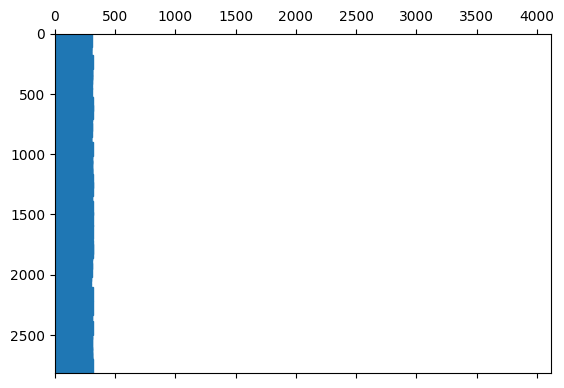

In [70]:
plt.spy(browscsc)
plt.show()

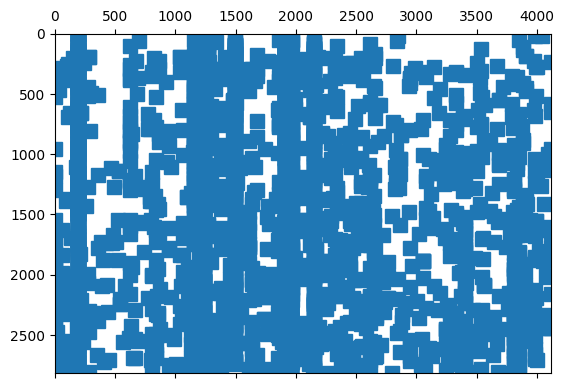

In [72]:
plt.spy(browsDER0)
plt.show()